In [1]:
import requests


In [2]:
url = "https://www.amazon.in/dp/B0FZT1LXPZ/?_encoding=UTF8&ref_=cct_cg_Budget_2a1&pf_rd_p=7ddb18be-d699-4268-b685-a3ff49933eb4&pf_rd_r=AG8FAS20B5TZT4FWF2XQ&th=1"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print(response.status_code)


200


In [3]:
print(response.status_code)


200


In [19]:
import requests
from bs4 import BeautifulSoup

url = "https://www.amazon.in/dp/B0FZT1LXPZ/?_encoding=UTF8&ref_=cct_cg_Budget_2a1&pf_rd_p=7ddb18be-d699-4268-b685-a3ff49933eb4&pf_rd_r=AG8FAS20B5TZT4FWF2XQ&th=1"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept-Language": "en-IN,en;q=0.9"
}

response = requests.get(url, headers=headers)
html = response.text
soup = BeautifulSoup(html, "html.parser")

print(response.status_code)
print(soup.title)


200
<title>OnePlus 15R | 12GB+256GB | Mint Breeze | World's First Snapdragon® 8 Gen 5 | 7400mAh Battery | Personalised AI | Game-Changing 165Hz Display | IP66 IP68 IP69 &amp; IP69K | 4K 120fps Video : Amazon.in: Electronics</title>


In [20]:
found = False

for span in soup.find_all("span"):
    text = span.text.strip()
    if "₹" in text:
        print("FOUND PRICE:", text)
        found = True
        break

if not found:
    print("No price found in HTML")


FOUND PRICE: ₹47,999.00₹47,999.00


In [22]:
price = soup.find("span", class_="a-offscreen")
print(price)


<span class="a-offscreen">₹47,999.00</span>


In [23]:
raw_price = price.text
print(raw_price)


₹47,999.00


In [24]:
clean_price = raw_price.replace("₹", "").replace(",", "").split(".")[0]
clean_price = int(clean_price)

print(clean_price)


47999


In [26]:
import csv
from datetime import date

today = date.today()

with open("../data/price_data.csv", "a", newline="") as file:
    writer = csv.writer(file)
    writer.writerow([today, clean_price])

print("Price saved to CSV")


Price saved to CSV


In [27]:
import pandas as pd


In [28]:
df = pd.read_csv("../data/price_data.csv")
df


,2026-01-02,47999
0,2026-01-02,47999


In [29]:
len(df)


1

In [32]:
df = pd.read_csv("../data/price_data.csv", header=None)
df.columns = ["date", "price"]
df


,date,price
0,2026-01-02,47999
1,2026-01-02,47999


In [33]:
len(df)


2

In [34]:
print("Min price:", df["price"].min())
print("Max price:", df["price"].max())
print("Average price:", df["price"].mean())


Min price: 47999
Max price: 47999
Average price: 47999.0


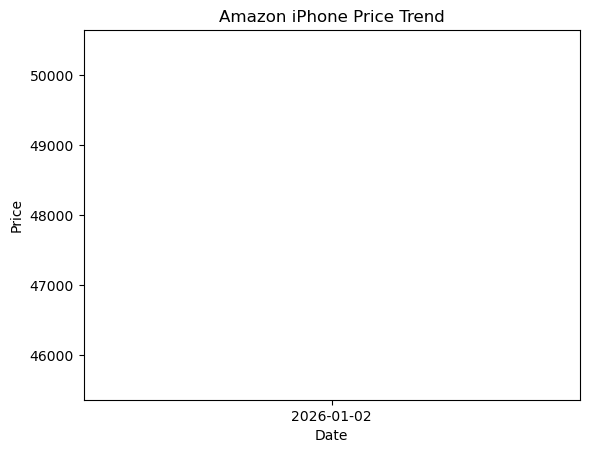

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["date"], df["price"])
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Amazon iPhone Price Trend")
plt.show()


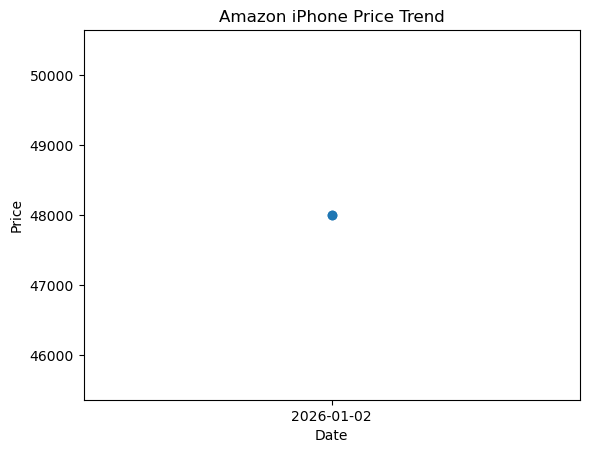

In [36]:
plt.figure()
plt.plot(df["date"], df["price"], marker="o")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Amazon iPhone Price Trend")
plt.show()


In [37]:
df = df.sort_values("date").reset_index(drop=True)
df


,date,price
0,2026-01-02,47999
1,2026-01-02,47999


In [42]:
df["date"] = pd.to_datetime(df["date"])
df


,date,price
0,2026-01-02,47999
1,2026-01-02,47999


In [43]:
df["day"] = (df["date"] - df["date"].min()).dt.days
df


,date,price,day
0,2026-01-02,47999,0
1,2026-01-02,47999,0


In [44]:
X = df[["day"]]
y = df["price"]


In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
next_day = [[df["day"].max() + 1]]
predicted_price = model.predict(next_day)

print("Predicted next price:", int(predicted_price[0]))


Predicted next price: 47999


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [47]:
X = df[["day"]]


In [48]:
import pandas as pd

next_day_df = pd.DataFrame(
    {"day": [df["day"].max() + 1]}
)

predicted_price = model.predict(next_day_df)

print("Predicted next price:", int(predicted_price[0]))


Predicted next price: 47999
